<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week14/Day6/ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

> **Google Colab instructions:** Run the cells in order. When the upload button appears, select `AB_Test_Results.zip` directly. You do not need to unzip it manually.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [1]:
import io
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, shapiro
from google.colab import files

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Upload the ZIP or CSV file downloaded from the course platform
uploaded = files.upload()

uploaded_names = list(uploaded.keys())

if not uploaded_names:
    raise FileNotFoundError("No file was uploaded.")

uploaded_path = Path(uploaded_names[0])

# If a ZIP was uploaded, extract it and locate the CSV file
if uploaded_path.suffix.lower() == ".zip":
    extraction_folder = Path("/content/ab_test_data")
    extraction_folder.mkdir(exist_ok=True)

    with zipfile.ZipFile(uploaded_path, "r") as zip_ref:
        zip_ref.extractall(extraction_folder)

    csv_files = list(extraction_folder.rglob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(
            "The ZIP file does not contain a CSV file."
        )

    dataset_path = max(
        csv_files,
        key=lambda path: path.stat().st_size
    )

elif uploaded_path.suffix.lower() == ".csv":
    dataset_path = uploaded_path

else:
    raise ValueError(
        "Please upload the AB_Test_Results ZIP or CSV file."
    )

df = pd.read_csv(dataset_path)

print("✅ Dataset loaded successfully")
print("Dataset path:", dataset_path)
print("Shape:", df.shape)

Saving AB_Test_Results.zip to AB_Test_Results.zip
✅ Dataset loaded successfully
Dataset path: /content/ab_test_data/AB_Test_Results/AB_Test_Results.csv
Shape: (10000, 3)


In [3]:
# Take a quick look at the data
display(df.head())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all"))

print("\nMissing values:")
display(df.isna().sum().rename("missing_values").to_frame())

print("\nDuplicated rows:", df.duplicated().sum())

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
1,2423,control,0.0
2,9411,control,0.0
3,7311,control,0.0
4,6174,variant,0.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB

Summary statistics:


,USER_ID,VARIANT_NAME,REVENUE
count,10000.000000,10000,10000.000000
unique,NaN,2,NaN
top,NaN,variant,NaN
freq,NaN,5016,NaN
mean,4981.080200,NaN,0.099447
std,2890.590115,NaN,2.318529
min,2.000000,NaN,0.000000
25%,2468.750000,NaN,0.000000
50%,4962.000000,NaN,0.000000
75%,7511.500000,NaN,0.000000



Missing values:


,missing_values
USER_ID,0
VARIANT_NAME,0
REVENUE,0



Duplicated rows: 2067


Let's see if there are users who have two A/B test groups

In [4]:
# Distribution of the number of unique A/B groups for each user
groups_per_user = (
    df.groupby("USER_ID")["VARIANT_NAME"]
      .nunique()
)

group_count_distribution = (
    groups_per_user
      .value_counts()
      .sort_index()
)

display(
    group_count_distribution
      .rename("number_of_users")
      .to_frame()
)

,number_of_users
VARIANT_NAME,
1,4783
2,1541


In [5]:
# Relative distribution of the number of unique groups per user
relative_group_distribution = (
    groups_per_user
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
      .round(2)
)

display(
    relative_group_distribution
      .rename("percentage_of_users")
      .to_frame()
)

,percentage_of_users
VARIANT_NAME,
1,75.63
2,24.37


### Observation

Most users belong to only one A/B test group, but some users appear in both the control and variant groups.

These users should be excluded because their exposure is contaminated: we cannot attribute their behavior to only one experimental condition. Keeping them would violate the independence of the control and treatment groups and could bias the results.


In [6]:
# Identify users who belong to exactly one A/B test group
users_with_one_group = groups_per_user[
    groups_per_user == 1
].index

print(
    "Users with exactly one group:",
    len(users_with_one_group)
)

# Keep only these users
df = df[
    df["USER_ID"].isin(users_with_one_group)
].copy()

print("Rows after removing mixed-group users:", len(df))
print("Unique users remaining:", df["USER_ID"].nunique())

Users with exactly one group: 4783
Rows after removing mixed-group users: 6070
Unique users remaining: 4783


In [7]:
# Verify that every remaining user belongs to only one group
remaining_groups_per_user = (
    df.groupby("USER_ID")["VARIANT_NAME"]
      .nunique()
)

assert remaining_groups_per_user.eq(1).all(), (
    "Some users still belong to more than one group."
)

assert df["USER_ID"].nunique() == len(users_with_one_group), (
    "The number of users does not match the expected value."
)

print("✅ Every remaining user belongs to exactly one group")
print("Verified users:", df["USER_ID"].nunique())

display(
    df.groupby("VARIANT_NAME")["USER_ID"]
      .nunique()
      .rename("unique_users")
      .to_frame()
)

✅ Every remaining user belongs to exactly one group
Verified users: 4783


,unique_users
VARIANT_NAME,
control,2390
variant,2393


Let's see how the data is distributed

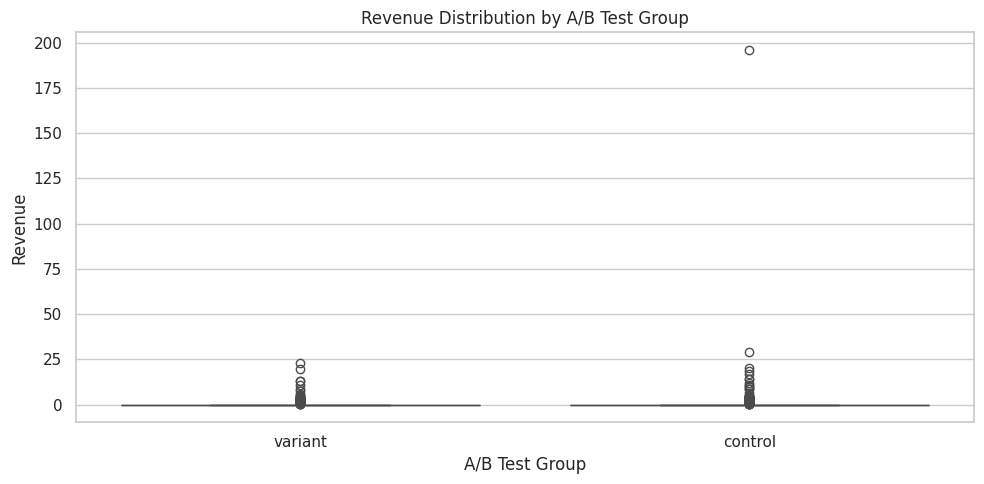

In [8]:
# Check the revenue distribution with a box plot
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="VARIANT_NAME",
    y="REVENUE"
)

plt.title("Revenue Distribution by A/B Test Group")
plt.xlabel("A/B Test Group")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

It can be seen that there is a strong outlier in the data - we will find it by sorting these revenue values in descending order

In [9]:
# Sort revenue values in descending order
display(
    df.sort_values(
        "REVENUE",
        ascending=False
    ).head(15)
)

,USER_ID,VARIANT_NAME,REVENUE
1437,3342,control,196.01
8168,2166,control,29.32
2482,7356,variant,23.04
6412,1053,control,20.07
5217,3684,variant,19.47
5530,282,control,18.56
758,4445,control,17.05
4031,2059,control,14.24
9019,1973,control,14.07
4561,4966,variant,12.99


In [10]:
# Check all records belonging to user 3342
display(
    df[df["USER_ID"] == 3342]
      .sort_values("REVENUE", ascending=False)
)

,USER_ID,VARIANT_NAME,REVENUE
1437,3342,control,196.01


We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

Rows removed: 1


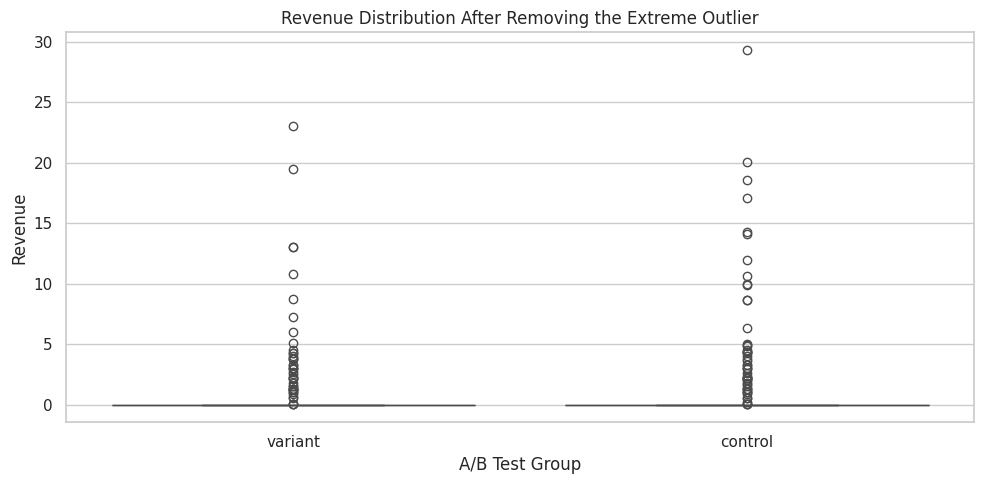

In [11]:
# Remove the extreme outlier associated with user 3342
rows_before = len(df)

df = df[
    ~(
        (df["USER_ID"] == 3342)
        & (df["REVENUE"] == df["REVENUE"].max())
    )
].copy()

print("Rows removed:", rows_before - len(df))

# Visualize the distribution again
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="VARIANT_NAME",
    y="REVENUE"
)

plt.title("Revenue Distribution After Removing the Extreme Outlier")
plt.xlabel("A/B Test Group")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Observation

Most visits generated no revenue, while only a small proportion generated a purchase. The revenue distribution is therefore highly right-skewed and contains many zero values.

Some users appear more than once because the original rows represent visits or events rather than one row per experimental user.


In [12]:
# Check whether users have both zero and positive revenue records
user_revenue_behavior = (
    df.groupby("USER_ID")["REVENUE"]
      .agg(
          minimum_revenue="min",
          maximum_revenue="max",
          record_count="count"
      )
)

users_with_zero_and_positive = user_revenue_behavior[
    (user_revenue_behavior["minimum_revenue"] == 0)
    & (user_revenue_behavior["maximum_revenue"] > 0)
]

print(
    "Users with both zero and positive revenue records:",
    len(users_with_zero_and_positive)
)

display(users_with_zero_and_positive.head())

Users with both zero and positive revenue records: 37


,minimum_revenue,maximum_revenue,record_count
USER_ID,,,
124,0.0,1.25,3
169,0.0,4.33,2
282,0.0,18.56,2
443,0.0,3.75,3
487,0.0,4.33,2


### Answer

Yes. A user can have records with both zero and positive revenue because each record can represent a separate visit. A user may visit without purchasing and later return and make a purchase.

Since randomization occurred at the user level, the correct experimental unit is the user. We therefore aggregate all visits for each user before performing the statistical comparison.


In [13]:
# Aggregate revenue so that each user has one record
df = (
    df.groupby(
        ["USER_ID", "VARIANT_NAME"],
        as_index=False
    )["REVENUE"]
     .sum()
)

print("Rows after aggregation:", len(df))
print("Unique users:", df["USER_ID"].nunique())

display(df.head())

Rows after aggregation: 4782
Unique users: 4782


,USER_ID,VARIANT_NAME,REVENUE
0,2,control,0.0
1,4,variant,0.0
2,5,variant,0.0
3,6,variant,0.0
4,9,variant,0.0


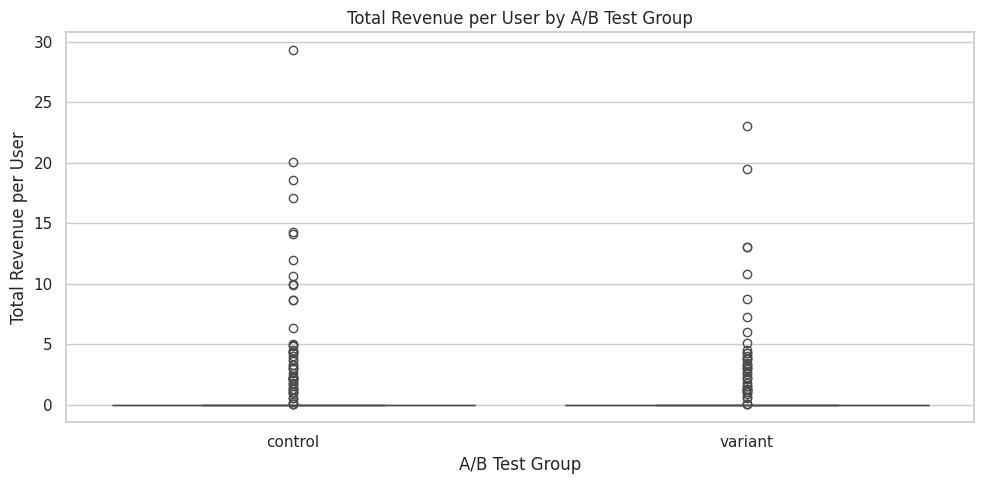

,count,mean,std,min,25%,50%,75%,max
VARIANT_NAME,,,,,,,,
control,2389.0,0.114923,1.162495,0.0,0.0,0.0,0.0,29.32
variant,2393.0,0.074935,0.858207,0.0,0.0,0.0,0.0,23.04


In [14]:
# Visualize the user-level revenue distribution
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="VARIANT_NAME",
    y="REVENUE"
)

plt.title("Total Revenue per User by A/B Test Group")
plt.xlabel("A/B Test Group")
plt.ylabel("Total Revenue per User")
plt.tight_layout()
plt.show()

display(
    df.groupby("VARIANT_NAME")["REVENUE"]
      .describe()
)

It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [15]:
# Metrics for all users
all_user_metrics = (
    df.groupby("VARIANT_NAME")
      .agg(
          total_users=("USER_ID", "nunique"),
          total_revenue=("REVENUE", "sum"),
          paying_users=("REVENUE", lambda values: (values > 0).sum()),
          average_revenue_per_user=("REVENUE", "mean"),
          median_revenue_per_user=("REVENUE", "median")
      )
)

# Additional relative metrics
all_user_metrics["conversion_rate"] = (
    all_user_metrics["paying_users"]
    / all_user_metrics["total_users"]
)

all_user_metrics["revenue_per_paying_user"] = (
    all_user_metrics["total_revenue"]
    / all_user_metrics["paying_users"]
)

display(all_user_metrics.round(4))

# Relative change from control to variant
relative_change_all = (
    (
        all_user_metrics.loc["variant"]
        / all_user_metrics.loc["control"]
    ) - 1
).mul(100)

display(
    relative_change_all
      .rename("variant_vs_control_change_percent")
      .round(2)
      .to_frame()
)

,total_users,total_revenue,paying_users,average_revenue_per_user,median_revenue_per_user,conversion_rate,revenue_per_paying_user
VARIANT_NAME,,,,,,,
control,2389,274.55,53,0.1149,0.0,0.0222,5.1802
variant,2393,179.32,42,0.0749,0.0,0.0176,4.2695


,variant_vs_control_change_percent
total_users,0.17
total_revenue,-34.69
paying_users,-20.75
average_revenue_per_user,-34.80
median_revenue_per_user,NaN
conversion_rate,-20.89
revenue_per_paying_user,-17.58


### Observation

After cleaning and aggregating at the user level, the variant group does **not** show an improvement in the main revenue metrics.

Compared with the control group, the variant has lower:

- Total revenue
- Average revenue per user
- Number of paying users
- Conversion rate

The groups contain almost the same number of users, so the difference is not explained by a major sample-size imbalance. Statistical testing is still required to determine whether the observed difference is significant.


In [16]:
# Keep only paying users
paying_users_df = df[df["REVENUE"] > 0].copy()

# Metrics for paying users
paying_user_metrics = (
    paying_users_df.groupby("VARIANT_NAME")
      .agg(
          paying_users=("USER_ID", "nunique"),
          total_revenue=("REVENUE", "sum"),
          average_revenue_per_paying_user=("REVENUE", "mean"),
          median_revenue_per_paying_user=("REVENUE", "median"),
          minimum_revenue=("REVENUE", "min"),
          maximum_revenue=("REVENUE", "max")
      )
)

paying_user_metrics["share_of_total_users"] = (
    paying_user_metrics["paying_users"]
    / df.groupby("VARIANT_NAME")["USER_ID"].nunique()
)

display(paying_user_metrics.round(4))

# Relative change from control to variant
relative_change_paid = (
    (
        paying_user_metrics.loc["variant"]
        / paying_user_metrics.loc["control"]
    ) - 1
).mul(100)

display(
    relative_change_paid
      .rename("variant_vs_control_change_percent")
      .round(2)
      .to_frame()
)

,paying_users,total_revenue,average_revenue_per_paying_user,median_revenue_per_paying_user,minimum_revenue,maximum_revenue,share_of_total_users
VARIANT_NAME,,,,,,,
control,53,274.55,5.1802,2.99,0.02,29.32,0.0222
variant,42,179.32,4.2695,2.97,0.02,23.04,0.0176


,variant_vs_control_change_percent
paying_users,-20.75
total_revenue,-34.69
average_revenue_per_paying_user,-17.58
median_revenue_per_paying_user,-0.67
minimum_revenue,0.00
maximum_revenue,-21.42
share_of_total_users,-20.89


Let's look at the distributions of all and only paying users

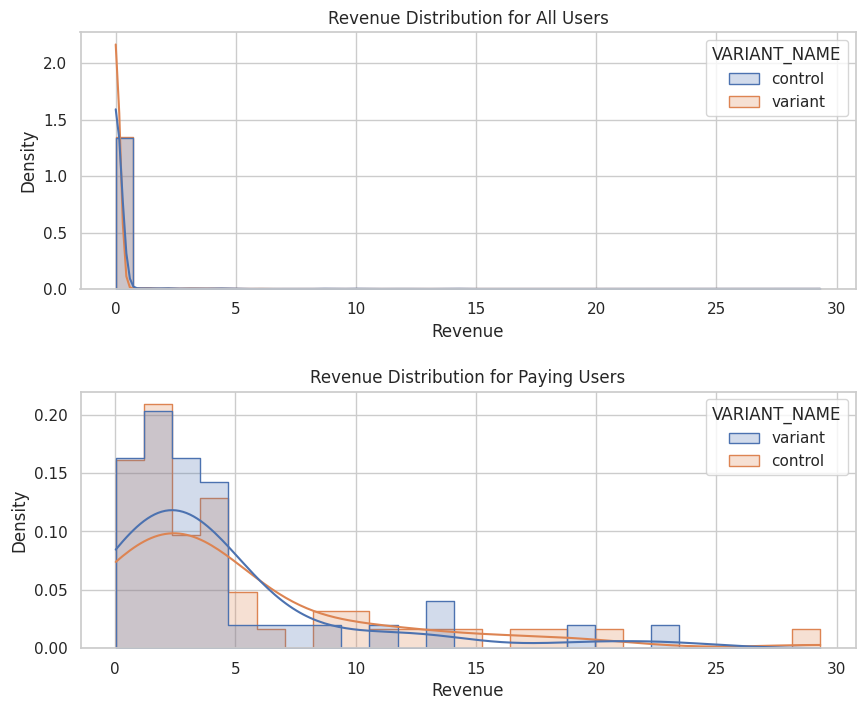

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Distributions for all users
sns.histplot(
    data=df,
    x="REVENUE",
    hue="VARIANT_NAME",
    bins=40,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0]
)

axes[0].set_title("Revenue Distribution for All Users")
axes[0].set_xlabel("Revenue")

# Distributions for paying users
sns.histplot(
    data=paying_users_df,
    x="REVENUE",
    hue="VARIANT_NAME",
    bins=25,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1]
)

axes[1].set_title("Revenue Distribution for Paying Users")
axes[1].set_xlabel("Revenue")

plt.subplots_adjust(hspace=0.4)
plt.show()

### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed.

In [18]:
# Shapiro-Wilk normality test
control_revenue = df.loc[
    df["VARIANT_NAME"] == "control",
    "REVENUE"
].to_numpy()

variant_revenue = df.loc[
    df["VARIANT_NAME"] == "variant",
    "REVENUE"
].to_numpy()

shapiro_results = pd.DataFrame({
    "group": ["control", "variant"],
    "statistic": [
        shapiro(control_revenue).statistic,
        shapiro(variant_revenue).statistic
    ],
    "p_value": [
        shapiro(control_revenue).pvalue,
        shapiro(variant_revenue).pvalue
    ]
})

display(shapiro_results)

,group,statistic,p_value
0,control,0.074612,2.123596e-75
1,variant,0.061460,9.962811e-76


### Answer

Yes. The Shapiro-Wilk p-values are far below `0.05`, so we reject the null hypothesis that revenue follows a normal distribution in both groups.

This result is consistent with the visualizations: the data contain many zeros and a small number of relatively large purchases, producing a strongly right-skewed distribution.


#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [19]:
(df['REVENUE'] == 0).value_counts()

,count
REVENUE,
True,4687
False,95


In [20]:
# Mann-Whitney U test for all users
mann_whitney_all = mannwhitneyu(
    control_revenue,
    variant_revenue,
    alternative="two-sided"
)

print("Mann-Whitney U test — all users")
print("Statistic:", mann_whitney_all.statistic)
print("P-value:", mann_whitney_all.pvalue)

if mann_whitney_all.pvalue < 0.05:
    print("Result: statistically significant difference.")
else:
    print("Result: no statistically significant difference.")

Mann-Whitney U test — all users
Statistic: 2871768.0
P-value: 0.24799555106821947
Result: no statistically significant difference.


In [21]:
# Mann-Whitney U test for paying users only
control_paid_revenue = paying_users_df.loc[
    paying_users_df["VARIANT_NAME"] == "control",
    "REVENUE"
].to_numpy()

variant_paid_revenue = paying_users_df.loc[
    paying_users_df["VARIANT_NAME"] == "variant",
    "REVENUE"
].to_numpy()

mann_whitney_paid = mannwhitneyu(
    control_paid_revenue,
    variant_paid_revenue,
    alternative="two-sided"
)

print("Mann-Whitney U test — paying users")
print("Statistic:", mann_whitney_paid.statistic)
print("P-value:", mann_whitney_paid.pvalue)

if mann_whitney_paid.pvalue < 0.05:
    print("Result: statistically significant difference.")
else:
    print("Result: no statistically significant difference.")

Mann-Whitney U test — paying users
Statistic: 1197.0
P-value: 0.5314192217084708
Result: no statistically significant difference.


#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [22]:
def get_bootstrap_samples(data, n_samples=5000, random_state=42):
    """Generate bootstrap samples with replacement."""
    data = np.asarray(data)
    rng = np.random.default_rng(random_state)

    indices = rng.integers(
        0,
        len(data),
        size=(n_samples, len(data))
    )

    return data[indices]


def stat_intervals(stat, alpha=0.05):
    """Return the percentile confidence interval."""
    return np.percentile(
        stat,
        [
            100 * alpha / 2,
            100 * (1 - alpha / 2)
        ]
    )

In [23]:
# Generate bootstrap samples for all users
control = get_bootstrap_samples(
    control_revenue,
    n_samples=5000,
    random_state=42
)

variant = get_bootstrap_samples(
    variant_revenue,
    n_samples=5000,
    random_state=43
)

control_means = control.mean(axis=1)
variant_means = variant.mean(axis=1)

print(
    "Control mean 95% CI:",
    stat_intervals(control_means)
)

print(
    "Variant mean 95% CI:",
    stat_intervals(variant_means)
)

Control mean 95% CI: [0.07154688 0.1639572 ]
Variant mean 95% CI: [0.04344693 0.11378186]


In [24]:
# Generate bootstrap samples for paying users
control_paid = get_bootstrap_samples(
    control_paid_revenue,
    n_samples=5000,
    random_state=44
)

variant_paid = get_bootstrap_samples(
    variant_paid_revenue,
    n_samples=5000,
    random_state=45
)

control_paid_means = control_paid.mean(axis=1)
variant_paid_means = variant_paid.mean(axis=1)

print(
    "Control paying-user mean 95% CI:",
    stat_intervals(control_paid_means)
)

print(
    "Variant paying-user mean 95% CI:",
    stat_intervals(variant_paid_means)
)

Control paying-user mean 95% CI: [3.72565094 6.88004717]
Variant paying-user mean 95% CI: [2.92783929 5.88501786]


Let's look at the distribution of means in the ab test groups

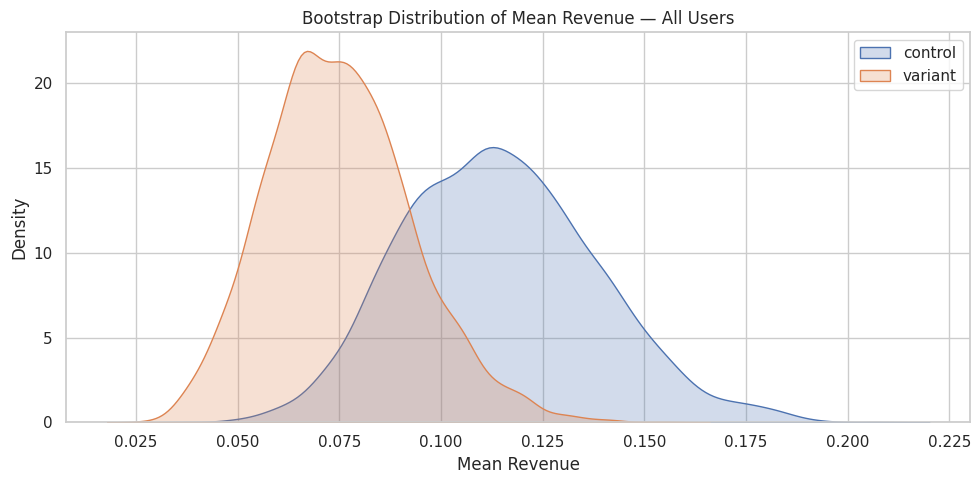

In [25]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    control_means,
    fill=True,
    label="control"
)

sns.kdeplot(
    variant_means,
    fill=True,
    label="variant"
)

plt.title("Bootstrap Distribution of Mean Revenue — All Users")
plt.xlabel("Mean Revenue")
plt.legend()
plt.tight_layout()
plt.show()

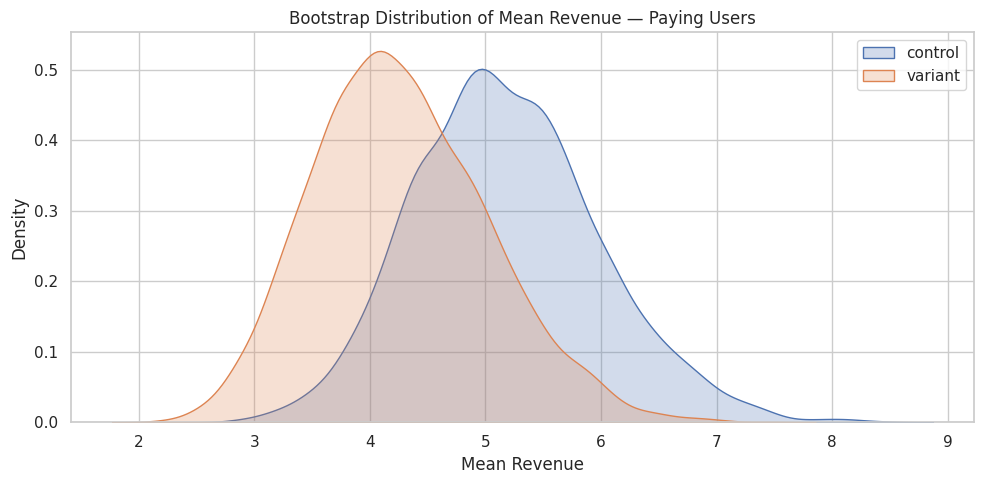

In [26]:
plt.figure(figsize=(10, 5))

sns.kdeplot(
    control_paid_means,
    fill=True,
    label="control"
)

sns.kdeplot(
    variant_paid_means,
    fill=True,
    label="variant"
)

plt.title("Bootstrap Distribution of Mean Revenue — Paying Users")
plt.xlabel("Mean Revenue")
plt.legend()
plt.tight_layout()
plt.show()

### Bootstrap observation

The bootstrap distributions overlap considerably for both all users and paying users.

The control group has a somewhat higher observed mean, but visual overlap alone does not establish a statistically reliable difference. The most useful quantity is the confidence interval for the difference:

`variant mean − control mean`

If this interval contains zero, the experiment does not provide sufficient evidence of a statistically significant change.


In [27]:
def plot_distribution_and_stat_intervals(
    variant_statistics,
    control_statistics,
    title,
    alpha=0.05
):
    """Plot bootstrap differences and return their confidence interval."""

    differences = (
        np.asarray(variant_statistics)
        - np.asarray(control_statistics)
    )

    confidence_interval = stat_intervals(
        differences,
        alpha
    )

    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        differences,
        fill=True
    )

    plt.axvline(
        0,
        label="No difference",
        linestyle="-"
    )

    plt.axvline(
        confidence_interval[0],
        linestyle="--",
        label="Lower CI bound"
    )

    plt.axvline(
        confidence_interval[1],
        linestyle="--",
        label="Upper CI bound"
    )

    plt.title(
        f"Bootstrap Difference in Means: Variant − Control ({title})"
    )

    plt.xlabel("Difference in Mean Revenue")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"{100 * (1 - alpha):.0f}% confidence interval:",
        confidence_interval
    )

    return confidence_interval

Let's build a graph of the distribution of the difference in the means and get a confidence interval

For all users

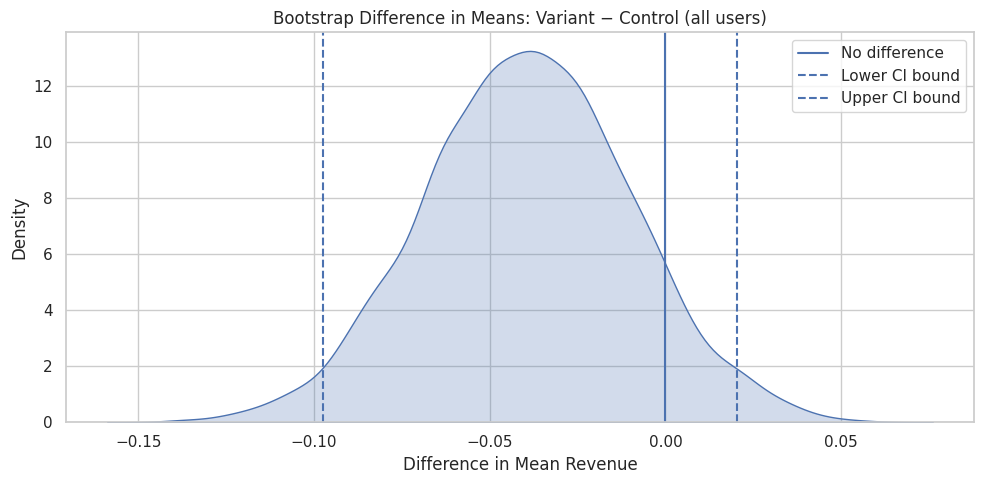

95% confidence interval: [-0.09735744  0.02034027]


In [28]:
all_users_difference_ci = plot_distribution_and_stat_intervals(
    variant_means,
    control_means,
    title="all users"
)

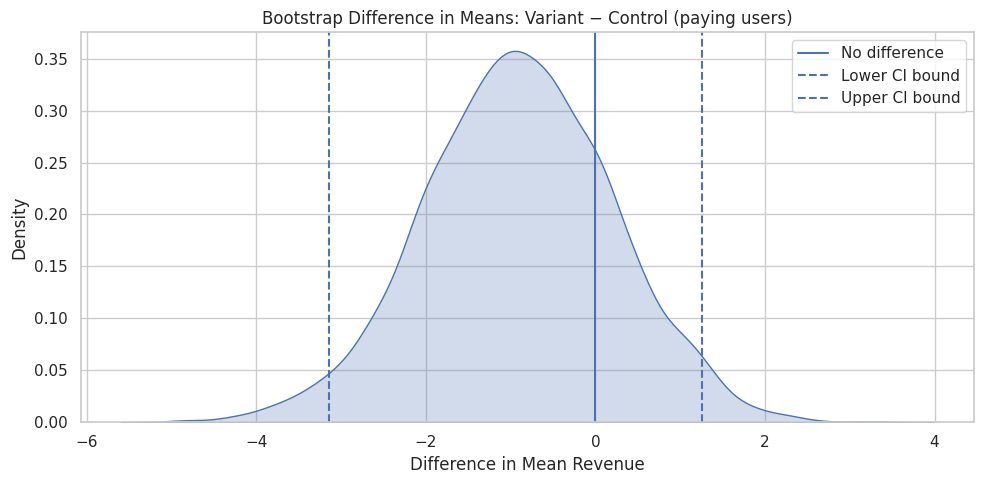

95% confidence interval: [-3.14329077  1.25222439]


In [29]:
paying_users_difference_ci = plot_distribution_and_stat_intervals(
    variant_paid_means,
    control_paid_means,
    title="paying users"
)

## Final conclusion

After cleaning the experiment data, removing users exposed to both groups, removing the single extreme outlier, and aggregating the data at the user level:

- The variant group has a lower observed average revenue than the control group.
- The variant also has fewer paying users and a lower conversion rate.
- Revenue is strongly non-normal because most users generated zero revenue.
- The Mann-Whitney tests for all users and paying users produce p-values above `0.05`.
- The bootstrap confidence intervals for the difference in means include zero.

Therefore, there is **no statistically significant evidence** that the variant changed average revenue relative to the control group.

The observed point estimates actually favor the control group, but the uncertainty is too large to conclude that the variant caused a real decrease. Based on this experiment alone, the new variant should not be launched as a revenue-improving change.
